In [1]:
from pathlib import Path
import subprocess

from IPython.display import SVG, display

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "bin").is_dir():
    PROJECT_DIR = PROJECT_DIR.parent

MATRIX_DIR = PROJECT_DIR / "data"
if not (MATRIX_DIR / "fastani-upper-triangle.parquet").is_file():
    MATRIX_DIR = PROJECT_DIR.parents[1] / PROJECT_DIR.name / "data"

ANI_PATH = MATRIX_DIR / "fastani-upper-triangle.parquet"
LCA_PATH = MATRIX_DIR / "LCA.parquet"
METADATA_PATH = PROJECT_DIR / "assets" / "genome_tax_metadata.parquet"
R_SCRIPT = PROJECT_DIR / "bin" / "figure3_ani_ridgeline_by_genus.R"
R_BIN = Path.home() / ".cache/conda-envs/ani-microbial-eukaryotes-notebook/bin/Rscript"
if not R_BIN.is_file():
    R_BIN = Path("/home/bin/Rscript")

for required_path in (ANI_PATH, LCA_PATH, METADATA_PATH, R_SCRIPT, R_BIN):
    if not required_path.is_file():
        raise FileNotFoundError(required_path)

FIGS_DIR = PROJECT_DIR / "assets" / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE3_PREFIX = FIGS_DIR / "fig-3"
FIGURE3_SVG = FIGURE3_PREFIX.with_suffix(".svg")

print(f"ANI matrix: {ANI_PATH}")
print(f"LCA matrix: {LCA_PATH}")
print(f"Taxonomy/QC metadata: {METADATA_PATH}")

ANI matrix: /home/.local/share/proj/ANI-microbial-eukaryotes-hetrick-2026/ANI-microbial-eukaryotes-hetrick-2026/data/fastani-upper-triangle.parquet
LCA matrix: /home/.local/share/proj/ANI-microbial-eukaryotes-hetrick-2026/ANI-microbial-eukaryotes-hetrick-2026/data/LCA.parquet
Taxonomy/QC metadata: /home/.local/share/proj/ANI-microbial-eukaryotes-hetrick-2026/new_clone/ANI-microbial-eukaryotes-hetrick-2026/assets/genome_tax_metadata.parquet


Picking joint bandwidth of 0.192
Picking joint bandwidth of 0.458
Picking joint bandwidth of 0.454
Picking joint bandwidth of 1.16
Picking joint bandwidth of 0.142
Picking joint bandwidth of 0.485
Picking joint bandwidth of 0.32
Picking joint bandwidth of 0.204
Picking joint bandwidth of 0.6
Warning message:
Removed 6 rows containing non-finite outside the scale range
(`stat_density_ridges()`). 
Picking joint bandwidth of 0.192
Picking joint bandwidth of 0.458
Picking joint bandwidth of 0.454
Picking joint bandwidth of 1.16
Picking joint bandwidth of 0.142
Picking joint bandwidth of 0.485
Picking joint bandwidth of 0.32
Picking joint bandwidth of 0.204
Picking joint bandwidth of 0.6
Warning message:
Removed 6 rows containing non-finite outside the scale range
(`stat_density_ridges()`). 
Picking joint bandwidth of 0.192
Picking joint bandwidth of 0.458
Picking joint bandwidth of 0.454
Picking joint bandwidth of 1.16
Picking joint bandwidth of 0.142
Picking joint bandwidth of 0.485
Picki

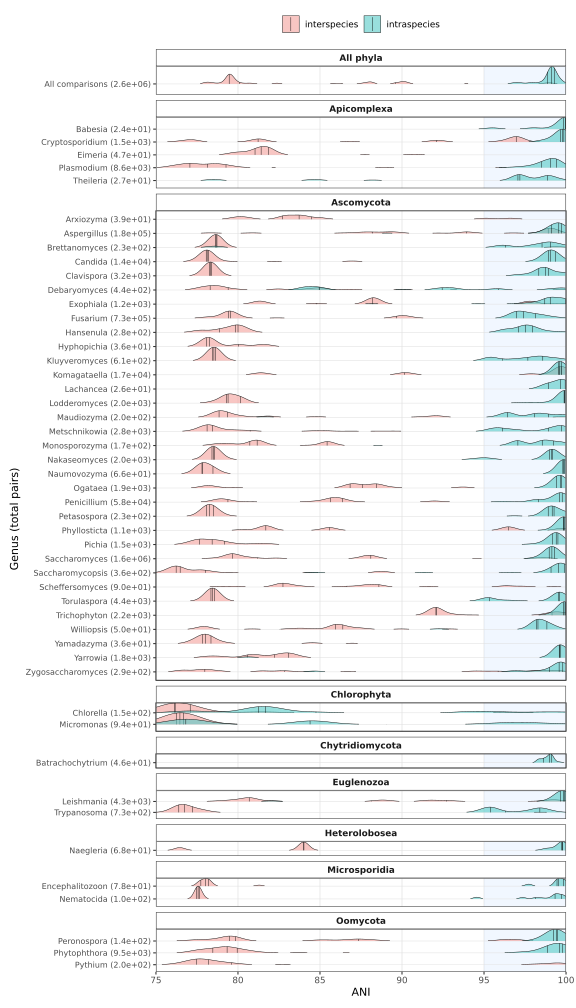

In [2]:
command = [
    str(R_BIN),
    str(R_SCRIPT),
    "--repo-root", str(PROJECT_DIR),
    "--ani-matrix", str(ANI_PATH),
    "--lca-matrix", str(LCA_PATH),
    "--metadata", str(METADATA_PATH),
    "--output-prefix", str(FIGURE3_PREFIX),
]
result = subprocess.run(command, check=True, text=True, capture_output=True)
if result.stdout.strip():
    print(result.stdout)
if result.stderr.strip():
    print(result.stderr)
display(SVG(filename=str(FIGURE3_SVG)))